In [2]:
# Data Preprocessing
#
# Objective:
# The main objective of this project is to design and implement a robust data
# preprocessing system that addresses common challenges such as missing values,
# outliers, inconsistent formatting, and noise.
#
# By performing effective data preprocessing, the project aims to enhance the
# quality, reliability, and usefulness of the data for machine learning.
#
# Dataset:
# https://drive.google.com/file/d/1F3lRf32JM8ejnXq-Cbf9y7fa57zSHGz_/view?usp=sharing
#
# Key Components to be fulfilled:


In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Employee.csv")
df.head()

Saving Employee.csv to Employee.csv


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [5]:
df.describe(include='all')

,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


In [6]:
#1. Data Exploration: (Score : 2).
#● Explore the data, list down the unique values in each feature and find its length.
#● Perform the statistical analysis and renaming of the columns.

In [7]:
summary = []

for column in df.columns:
    summary.append({
        "Feature": column,
        "Total Values (Length)": df[column].shape[0],
        "Number of Unique Values": df[column].nunique(),
        "Unique Values": df[column].unique()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Feature,Total Values (Length),Number of Unique Values,Unique Values
0,Company,148,6,"[TCS, Infosys, CTS, nan, Tata Consultancy Serv..."
1,Age,148,29,"[20.0, 30.0, 35.0, 40.0, 23.0, nan, 34.0, 45.0..."
2,Salary,148,40,"[nan, 2300.0, 3000.0, 4000.0, 5000.0, 6000.0, ..."
3,Place,148,11,"[Chennai, Mumbai, Calcutta, Delhi, Podicherry,..."
4,Country,148,1,[India]
5,Gender,148,2,"[0, 1]"


In [8]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [9]:
df.rename(columns={
    "Company": "company",
    "Age": "age",
    "Salary": "salary",
    "Place": "place",
    "Country": "country",
    "Gender": "gender"
}, inplace=True)

In [10]:
from IPython.display import display, Markdown

display(Markdown("""
### Statistical Analysis and Column Renaming

Basic descriptive statistics were used to study the numerical features in the dataset,
including age, salary, and gender. Measures such as mean, median, standard deviation,
minimum, and maximum values were analyzed to understand data distribution and to
identify missing or inappropriate values, such as zero values in the age column.

Categorical features were reviewed by examining their unique values and frequencies.
To maintain consistency and improve readability, all column names were converted to
lowercase. This step helps in standardizing the dataset and makes it easier to use
for further data cleaning, analysis, and machine learning tasks.
"""))



### Statistical Analysis and Column Renaming

Basic descriptive statistics were used to study the numerical features in the dataset,
including age, salary, and gender. Measures such as mean, median, standard deviation,
minimum, and maximum values were analyzed to understand data distribution and to
identify missing or inappropriate values, such as zero values in the age column.

Categorical features were reviewed by examining their unique values and frequencies.
To maintain consistency and improve readability, all column names were converted to
lowercase. This step helps in standardizing the dataset and makes it easier to use
for further data cleaning, analysis, and machine learning tasks.


In [11]:
#2. Data Cleaning: (Score : 2)
#● Find the missing and inappropriate values, treat them appropriately.
#● Remove all duplicate rows.
#● Find the outliers.
#● Replace the value 0 in age as NaN Treat the null values in all columns using any
#measures(removing/ replace the values with mean/median/mode) .

In [12]:
#Find the missing and inappropriate values, treat them appropriately.

In [13]:
df.isnull().sum()

,0
company,8
age,18
salary,24
place,14
country,0
gender,0


In [14]:
df[df['age'] == 0]

,company,age,salary,place,country,gender
88,Infosys,0.0,3030.0,Calcutta,India,0
92,TCS,0.0,3045.0,Delhi,India,0
101,CTS,0.0,2034.0,Podicherry,India,0
107,TCS,0.0,9024.0,Chennai,India,1
111,Infosys,0.0,3234.0,Mumbai,India,0
121,CTS,0.0,1234.0,Calcutta,India,0


In [15]:
df['age'] = df['age'].replace(0, np.nan)

In [16]:
# Treat numerical columns using median
df['age'] = df['age'].fillna(df['age'].median())
df['salary'] = df['salary'].fillna(df['salary'].median())

# Treat categorical columns using mode
df['company'] = df['company'].fillna(df['company'].mode()[0])
df['place'] = df['place'].fillna(df['place'].mode()[0])

In [17]:
df.isnull().sum()

,0
company,0
age,0
salary,0
place,0
country,0
gender,0


In [18]:
#Remove all duplicate rows.

In [19]:
df.duplicated().sum()

np.int64(4)

In [20]:
df = df.drop_duplicates()

In [21]:
#Find the outliers.

Number of age outliers: 0
Age outliers: Series([], Name: age, dtype: float64)
No outliers detected in age column


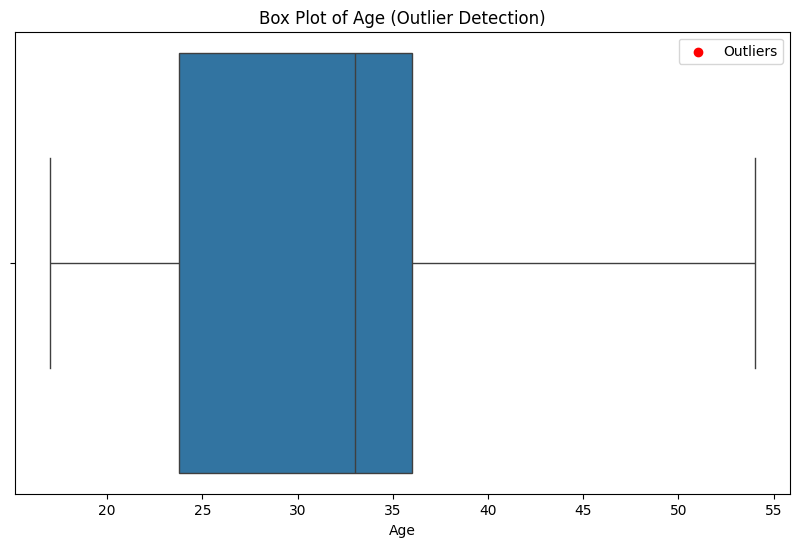

In [43]:
# Visualizing Outliers for Age

import matplotlib.pyplot as plt
import seaborn as sns

# Identify age outliers using IQR
Q1_age = df['age'].quantile(0.25)
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

age_outliers = df[
    (df['age'] < Q1_age - 1.5 * IQR_age) |
    (df['age'] > Q3_age + 1.5 * IQR_age)
]['age']

print("Number of age outliers:", len(age_outliers))
print("Age outliers:", age_outliers)
if len(age_outliers) == 0:
    print("No outliers detected in age column")

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df['age'],
    showfliers=True,
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markersize=6,
        linestyle='none'
    )
)

plt.scatter(
    age_outliers,
    np.zeros_like(age_outliers),
    color='red',
    label='Outliers'
)

plt.title("Box Plot of Age (Outlier Detection)")
plt.xlabel("Age")
plt.legend()
plt.show()

Number of salary outliers: 0
Salary outliers: Series([], Name: salary, dtype: float64)
No outliers detected in salary column


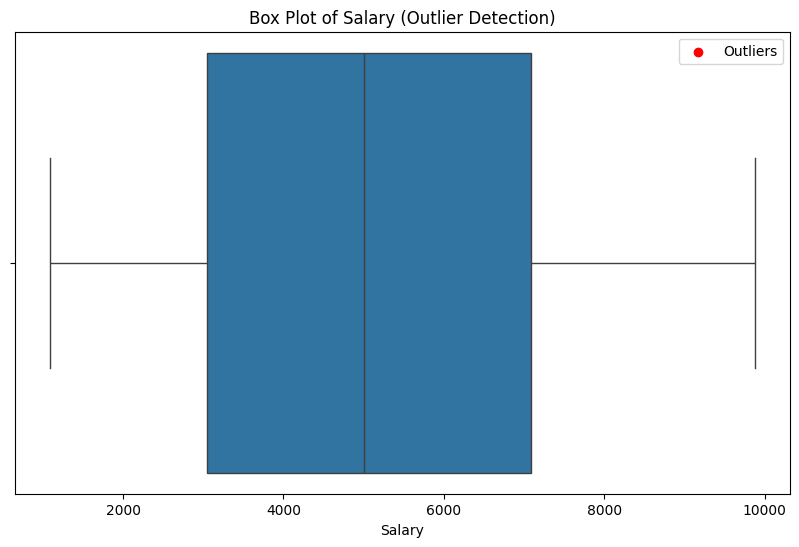

In [44]:
# Visualizing Outliers for Salary

# Identify salary outliers using IQR
Q1_sal = df['salary'].quantile(0.25)
Q3_sal = df['salary'].quantile(0.75)
IQR_sal = Q3_sal - Q1_sal

salary_outliers = df[
    (df['salary'] < Q1_sal - 1.5 * IQR_sal) |
    (df['salary'] > Q3_sal + 1.5 * IQR_sal)
]['salary']

print("Number of salary outliers:", len(salary_outliers))
print("Salary outliers:", salary_outliers)
if len(salary_outliers) == 0:
    print("No outliers detected in salary column")


plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df['salary'],
    showfliers=True,
    flierprops=dict(
        marker='o',
        markerfacecolor='red',
        markersize=6,
        linestyle='none'
    )
)

plt.scatter(
    salary_outliers,
    np.zeros_like(salary_outliers),
    color='red',
    label='Outliers'
)

plt.title("Box Plot of Salary (Outlier Detection)")
plt.xlabel("Salary")
plt.legend()
plt.show()

In [25]:
#3. Data Analysis: (Score : 2)
#● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
#Count the number of people from each place and represent it visually

In [26]:
filtered_df = df[(df['age'] > 40) & (df['salary'] < 5000)]
filtered_df

,company,age,salary,place,country,gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
86,Infosys,41.0,3000.0,Delhi,India,0
93,Infosys,54.0,3184.0,Mumbai,India,0
104,Infosys,44.0,4034.0,Delhi,India,0


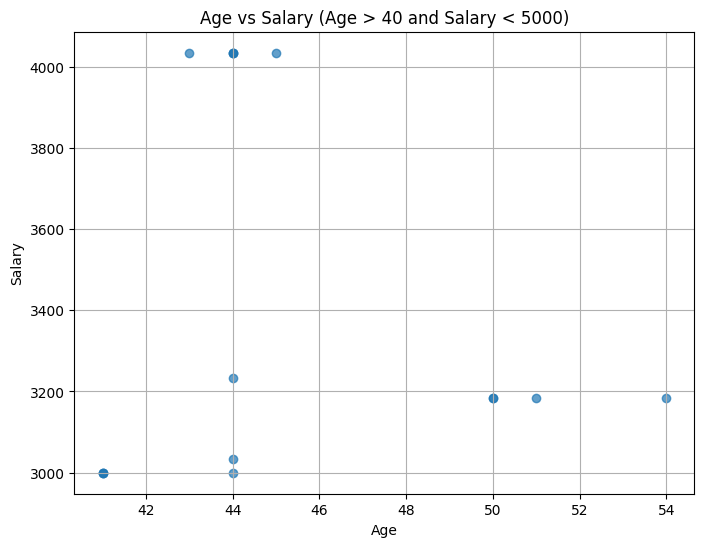

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['age'], filtered_df['salary'], alpha=0.7)
plt.title("Age vs Salary (Age > 40 and Salary < 5000)")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

In [32]:
place_counts = df['place'].value_counts().reset_index()
place_counts.columns = ['place', 'count']
place_counts

,place,count
0,Mumbai,48
1,Calcutta,32
2,Chennai,14
3,Delhi,14
4,Cochin,13
5,Noida,8
6,Hyderabad,8
7,Podicherry,3
8,Pune,2
9,Bhopal,1


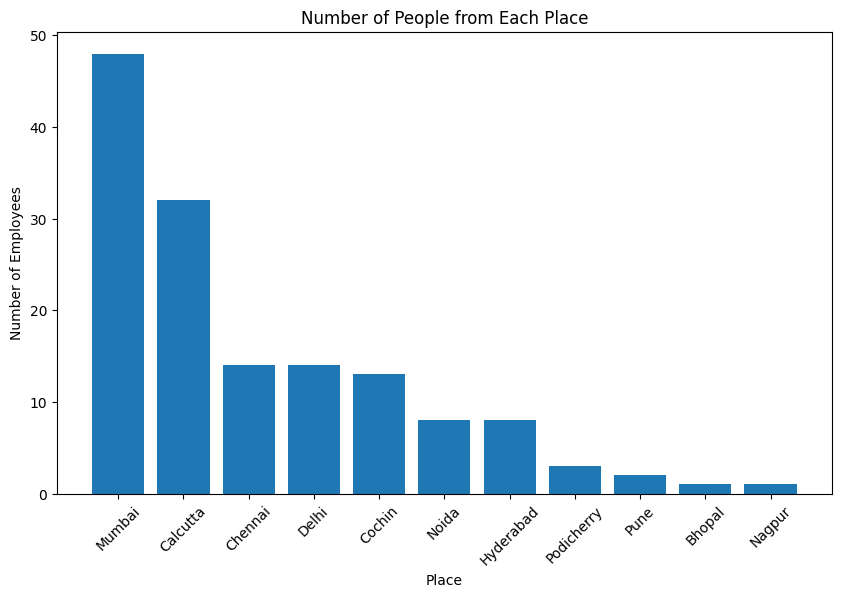

In [36]:
plt.figure(figsize=(10, 6))
plt.bar(place_counts['place'], place_counts['count'])
plt.xticks(rotation=45)
plt.title("Number of People from Each Place")
plt.xlabel("Place")
plt.ylabel("Number of Employees")
plt.show()


In [37]:
from IPython.display import display, Markdown

display(Markdown("""
### Data Analysis Summary

The dataset was filtered to include employees whose age is greater than 40 and whose
salary is less than 5000. This filtered data was used to study the relationship between
age and salary.

A scatter plot was created to visualize how salary varies with age for this group.
In addition, the number of employees from each place was counted and represented using
a bar chart. This analysis helps in understanding the age–salary pattern and the
distribution of employees across different locations.
"""))



### Data Analysis Summary

The dataset was filtered to include employees whose age is greater than 40 and whose
salary is less than 5000. This filtered data was used to study the relationship between
age and salary.

A scatter plot was created to visualize how salary varies with age for this group.
In addition, the number of employees from each place was counted and represented using
a bar chart. This analysis helps in understanding the age–salary pattern and the
distribution of employees across different locations.


In [38]:
#4. Data Encoding: (Score : 2)
#● Convert categorical variables into numerical representations using techniques
#such as one-hot encoding, label encoding, making them suitable for analysis by
#machine learning algorithms.

In [39]:
df.select_dtypes(include='object').columns

Index(['company', 'place', 'country'], dtype='object')

In [50]:
df_encoded = pd.get_dummies(
    df,
    columns=['company', 'place', 'country'],
    drop_first=True,
    dtype=int
)
df_encoded.head()


,age,salary,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,20.0,5000.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
1,30.0,5000.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,35.0,2300.0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
3,40.0,3000.0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
4,23.0,4000.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [41]:
#5. Feature Scaling: (Score : 2)
#● After the process of encoding, perform the scaling of the features using
#standardscaler and minmaxscaler.

In [42]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

num_cols = ['age', 'salary']

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

df_standard_scaled = df_encoded.copy()
df_minmax_scaled = df_encoded.copy()

df_standard_scaled[num_cols] = scaler_std.fit_transform(df_encoded[num_cols])
df_minmax_scaled[num_cols] = scaler_mm.fit_transform(df_encoded[num_cols])

df_standard_scaled.head(), df_minmax_scaled.head()


(        age    salary  gender  company_Congnizant  company_Infosys  \
 0 -1.484676 -0.100827       0               False            False   
 1 -0.267174 -0.100827       0               False             True   
 2  0.341577 -1.243735       0               False            False   
 3  0.950328 -0.947426       0               False             True   
 4 -1.119426 -0.524127       0               False            False   
 
    company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
 0                    False         True                              False   
 1                    False        False                              False   
 2                    False         True                              False   
 3                    False        False                              False   
 4                    False         True                              False   
 
    place_Calcutta  place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  \
 0           Fa